# WebSky Data Analysis
---
4 layers: CMB + tSZ + mu-distorted tSZ + noise
---
---

### Previous

In [1]:
### IMPORTS ###

import healpy as hp
import numpy as np
import pandas as pd
import scipy as sp
import numba as nb
import matplotlib.pyplot as plt

In [2]:
### MEMORY MANAGEMENT ###

import gc # Garbage Collector

# Before starting a new run, clear previous big variables if they exist
if 'data_cube' in locals():
    del data_cube
if 'alms_list' in locals():
    del alms_list
if 'y_hat_harmonic' in locals():
    del y_hat_harmonic
if 'y_hat_pixel' in locals():
    del y_hat_pixel
if 'residuals_harmonic' in locals():
    del residuals_harmonic
if 'residuals_pixel' in locals():
    del residuals_pixel

gc.collect() # Manually trigger memory cleanup

58

In [7]:
### DEFINITIONS: CONSTANTS, FREQUENCIES, ETC. ###

# Nside
nside_work = 2048

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Planck frequencies in GHz --- kickoff diapo. 8
frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857]

# Reference noise
base_sensitivity_uk_arcmin = 30.0

# Theoretical (LCDM) mu-distortion value
mu = 2e-3

# Calculate area of pixel in arcmin^2 for the working resolution. As hp.nside2pixarea gives us the area in steradians, we convert it to arcmin^2 by multiplying by (180*60/pi)^2
pixel_area_arcmin2 = hp.nside2pixarea(nside_work) * (180*60/np.pi)**2

### Data Reading & Writing

In [4]:
### 1. Load WebSky Components --- https://lambda.gsfc.nasa.gov/simulation/mocks_data.html --- CMB in muK units ###

# These are usually at high resolution (Nside 4096). 
# You might need to downgrade them to Nside 128 or 256 for faster testing.
path_to_websky = '/Users/joanribot/HEAVY_STUFF/TFM_data/WebSky_CMB_Mocks/'
path_to_processed_maps = '/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/'

# Set your working resolution and corresponding lmax
nside_work = 2048
#nside_work = 256

print("Reading WebSky maps...")

# A. Load tSZ, downgrade and save it
y_map_raw = hp.read_map(path_to_websky + "tsz.fits")
y_map = hp.ud_grade(y_map_raw, nside_out=nside_work)
#hp.write_map(path_to_websky + "tsz_downgraded.fits", y_map)
hp.write_map(path_to_processed_maps + "y_map.fits", y_map, coord='G', overwrite=True, dtype=np.float32)

# B. Load CMB alms and let it detect the original Lmax ######### CHECK UNITS FOR CMB TOO
# Use return_mmax=True to be extra safe with WebSky's format
alms_cmb, mmax_in = hp.read_alm(path_to_websky + "unlensed_alm.fits", hdu=1, return_mmax=True)

# C. Calculate the Lmax of the file data
lmax_in = hp.Alm.getlmax(len(alms_cmb), mmax_in)

# D. Convert to map. 
# We tell it the ALMs are at 'lmax_in', but we want the result at 'nside_work'
cmb_map = hp.alm2map(alms_cmb, nside=nside_work, lmax=lmax_in, mmax=mmax_in)

# E. Save the clean CMB map (in muK)
# This is your 'Ground Truth' for the CILC (which tries to remove this)
hp.write_map(path_to_processed_maps + "cmb_map.fits", cmb_map, coord='G', overwrite=True, dtype=np.float32)

print("WebSky maps loaded and saved at Nside 2048. Ready for the ILC process.")

Reading WebSky maps...


WebSky maps loaded and saved at Nside 2048. Ready for the ILC process.


In [5]:
### 2. Define the tSZ frequency scaling function g(nu) and Taylor expansion h(nu) ###

def get_physics_constants(nu):
    """Calculate the physics constants needed for tSZ scaling."""
    T_cmb = 2.7255     # CMB temperature in K
    k_B = 1.380649e-23 # Boltzmann constant in J/K
    h = 6.62607015e-34 # Planck constant in J*s
    x = (h * nu * 1e9) / (k_B * T_cmb) # Dimensionless frequency
    return x

def get_tsz_g(nu):
    """Calculate the tSZ frequency scaling g(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    g_nu = x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4 # or alternatively: g_nu = x * (1 / np.tanh(x / 2)) - 4
    return g_nu

def get_tsz_h(nu):
    """Calculate the tSZ Taylor expansion frequency scaling h(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    h_nu = (-x/2) * ( 1 / ( (np.exp(x) - np.exp(-x)) / 2 )**2 ) # or alternatively: h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    #h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    return h_nu

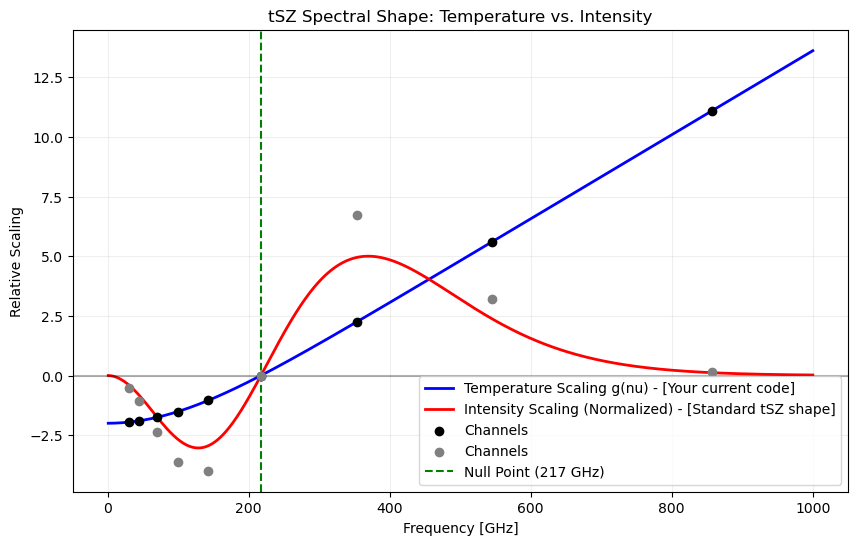

In [6]:
### 3. Compare the tSZ frequency scalings in Temperature and Intensity units ###

def get_tsz_g_temp(nu_ghz):
    """The function you currently have (Temperature units)"""
    x = get_physics_constants(nu_ghz)
    return x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4

def get_tsz_intensity_scaling(nu_ghz):
    """The Intensity distortion shape (MJy/sr units)"""
    x = get_physics_constants(nu_ghz)
    # This factor converts dT to dI
    conversion_factor = (x**4 * np.exp(x)) / (np.exp(x) - 1)**2
    return conversion_factor * get_tsz_g_temp(nu_ghz)

# Frequencies for plotting
nu = np.linspace(1, 1000, 1000)
frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz
g_temp = get_tsz_g_temp(nu)
g_int = get_tsz_intensity_scaling(nu)

# Normalize the Intensity scaling just for visual comparison
g_int_norm = g_int / np.max(np.abs(g_int))

plt.figure(figsize=(10, 6))
plt.plot(nu, g_temp, label="Temperature Scaling g(nu) - [Your current code]", color='blue', lw=2)
plt.plot(nu, g_int_norm * 5, label="Intensity Scaling (Normalized) - [Standard tSZ shape]", color='red', lw=2)

plt.scatter(frequencies, get_tsz_g(np.array(frequencies)), color='black', zorder=5, label=r"Channels")
plt.scatter(frequencies, get_tsz_intensity_scaling(np.array(frequencies)), color='gray', zorder=5, label=r"Channels")

plt.axhline(0, color='black', alpha=0.3)
plt.axvline(217, color='green', linestyle='--', label='Null Point (217 GHz)')

plt.title("tSZ Spectral Shape: Temperature vs. Intensity")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Relative Scaling")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [9]:
### 4. Create the noise and finally the data_cube_32 (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube_32 = []

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + noise_map + signal_mu_tsz
    data_cube_32.append(total_map)

data_cube_32 = np.array(data_cube_32, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_32 to FITS...")
hp.write_map("/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_9freq.fits", data_cube_32, 
             coord='G', column_names=[f"freq_{f}" for f in frequencies],
             overwrite=True, dtype=np.float32)

print("Data Cube (muK units) saved successfully as 'data_cube_32_9freq.fits'.")

# Now 'data_cube_32' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 30  GHz, Noise per pixel: 17.46 uK
Frequency: 44  GHz, Noise per pixel: 20.96 uK
Frequency: 70  GHz, Noise per pixel: 24.45 uK
Frequency: 100 GHz, Noise per pixel: 27.94 uK
Frequency: 143 GHz, Noise per pixel: 31.44 uK
Frequency: 217 GHz, Noise per pixel: 34.93 uK
Frequency: 353 GHz, Noise per pixel: 38.42 uK
Frequency: 545 GHz, Noise per pixel: 41.92 uK
Frequency: 857 GHz, Noise per pixel: 45.41 uK
Saving data_cube_32 to FITS...
Data Cube (muK units) saved successfully as 'data_cube_32_9freq.fits'.


In [7]:
### 5. Create the noise and finally the data_cube_64 (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube_64 = []

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + noise_map + signal_mu_tsz
    data_cube_64.append(total_map)

data_cube_64 = np.array(data_cube_64, dtype=np.float64) # Convert to numpy array for easier handling and ensure it's in float64 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_64 to FITS...")
hp.write_map("/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_64_9freq.fits", data_cube_64, 
             coord='G', column_names=[f"freq_{f}" for f in frequencies],
             overwrite=True, dtype=np.float64)

print("Data Cube (muK units) saved successfully as 'data_cube_64_9freq.fits'.")

# Now 'data_cube_64' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 30  GHz, Noise per pixel: 17.46 uK
Frequency: 44  GHz, Noise per pixel: 20.96 uK
Frequency: 70  GHz, Noise per pixel: 24.45 uK
Frequency: 100 GHz, Noise per pixel: 27.94 uK
Frequency: 143 GHz, Noise per pixel: 31.44 uK
Frequency: 217 GHz, Noise per pixel: 34.93 uK
Frequency: 353 GHz, Noise per pixel: 38.42 uK
Frequency: 545 GHz, Noise per pixel: 41.92 uK
Frequency: 857 GHz, Noise per pixel: 45.41 uK
Saving data_cube_64 to FITS...
Data Cube (muK units) saved successfully as 'data_cube_64_9freq.fits'.


### Checking $y$ \& $\mu y$ correlation

In [ ]:
### 6. Create the noise and finally the data_cube_no_muy (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube = []

print(f"--- Generating Data Cube (Nside={nside_work}) ---")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    #signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + noise_map
    data_cube.append(total_map)

data_cube = np.array(data_cube, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube to FITS...")
hp.write_map("/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_9freq_no_muy.fits", data_cube, 
             coord='G', column_names=[f"freq_{f}" for f in frequencies],
             overwrite=True, dtype=np.float32)

print("Data Cube without mu-distorted tSZ signal (muK units) saved successfully as 'data_cube_9freq_no_muy.fits'.")

# Now 'data_cube' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 30  GHz, Noise per pixel: 17.46 uK
Frequency: 44  GHz, Noise per pixel: 20.96 uK
Frequency: 70  GHz, Noise per pixel: 24.45 uK
Frequency: 100 GHz, Noise per pixel: 27.94 uK
Frequency: 143 GHz, Noise per pixel: 31.44 uK
Frequency: 217 GHz, Noise per pixel: 34.93 uK
Frequency: 353 GHz, Noise per pixel: 38.42 uK
Frequency: 545 GHz, Noise per pixel: 41.92 uK
Frequency: 857 GHz, Noise per pixel: 45.41 uK
Saving data_cube to FITS...
Data Cube without mu-distorted tSZ signal (muK units) saved successfully as 'data_cube_9freq_no_muy.fits'.


In [ ]:
### 7. Create the noise and finally the data_cube_no_y (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube = []

print(f"--- Generating Data Cube (Nside={nside_work}) ---")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    #signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + noise_map + signal_mu_tsz
    data_cube.append(total_map)

data_cube = np.array(data_cube, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube to FITS...")
hp.write_map("/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_9freq_no_y.fits", data_cube, 
             coord='G', column_names=[f"freq_{f}" for f in frequencies],
             overwrite=True, dtype=np.float32)

print("Data Cube without mu-distorted tSZ signal (muK units) saved successfully as 'data_cube_9freq_no_y.fits'.")

# Now 'data_cube' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---
Saving data_cube to FITS...
Data Cube without mu-distorted tSZ signal (muK units) saved successfully as 'data_cube_9freq_no_y.fits'.
